In [1]:
import numpy as np
import pandas as pd
import umap



/workspace/zhengqinyun/miniconda3/envs/TCRCellNet/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-18 08:48:12.369324: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-18 08:48:12.371304: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 08:48:12.406566: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 08:48:12.407400: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions 

ValueError: 'IGHV1-3;IGHJ2' is not in list

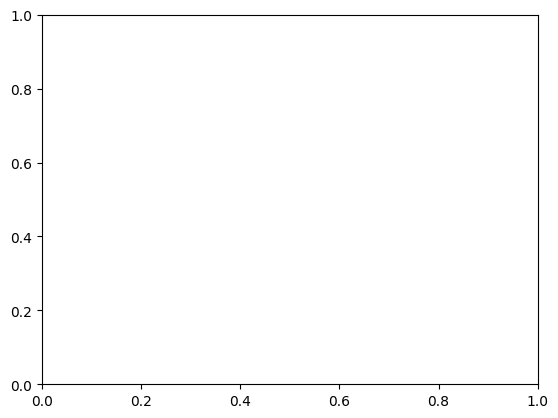

In [ ]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

plt.cla()
df = pd.read_csv("./df_VJ_all.csv")
df.fillna(0, inplace=True)
col_list = df.columns.tolist()
col_list[0] = "sample"
df.columns = col_list
arrange_dict = {}
arrange_list = ["PBMCs-sMPLC", "PBMCs-SPLC"]
for cate, i in zip(arrange_list, range(len(arrange_list))):
    arrange_dict[cate] = i
arrange_dict
colorlist = [[x] for x in df["Category"].map(arrange_dict)]
param_begin = df.columns.tolist().index("IGHV1-3;IGHJ2")
param_over = df.columns.tolist().index("TRAV14DV4;TRDJ3")
use_cols = df.columns[param_begin:param_over].tolist()
print(str(len(use_cols)) + " before remove")
remove_list = []
for remove_item in remove_list:
    use_cols.remove(remove_item)
print(str(len(use_cols)) + " after remove")
df[use_cols].values[0]
bio_data = np.array(df[df.columns[param_begin:param_over]].values, dtype=np.float32)
scaled_bio_data = StandardScaler().fit_transform(bio_data)
reducer = umap.UMAP(n_neighbors=6, min_dist=0.01, n_epochs=100, random_state=8)
embedding = reducer.fit_transform(scaled_bio_data)
scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=colorlist)
plt.legend(handles=scatter.legend_elements()[0], labels=arrange_dict.keys())
# for i in range(len(embedding[:, 0])):
#     plt.annotate(df["sample"].values.tolist()[i], xy = (embedding[:, 0][i], embedding[:, 1][i]), xytext = (embedding[:, 0][i]+0.1, embedding[:, 1][i]+0.1))
# plt.xticks([])
# plt.yticks([])
# df[["sample","category"]+df.columns[param_begin:param_over].tolist()].to_csv("1.csv",index=False)
plt.savefig("./VJ_p005.png", bbox_inches="tight", dpi=300)

In [ ]:
df

In [ ]:
# df["Age"]


In [ ]:

# bio_data=bio_data/bio_data.max()
scaled_bio_data = StandardScaler().fit_transform(bio_data)
reducer = umap.UMAP(n_neighbors=5,min_dist=0.01,n_epochs =50)
embedding = reducer.fit_transform(scaled_bio_data)
scatter = plt.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c = colorlist)
# for i in range(len(embedding[:, 0])):
#     plt.annotate(df["Group2"].values.tolist()[i], xy = (embedding[:, 0][i], embedding[:, 1][i]), xytext = (embedding[:, 0][i]+0.1, embedding[:, 1][i]+0.1)) 

In [ ]:
embedding.shape

In [ ]:
df.to_csv("48.csv",index=False)

In [ ]:
from statsmodels.stats.multitest import fdrcorrection as fdr
df = pd.read_csv("diversityparam.csv_Age_P_1.csv")
pvalues = np.array(df[df.columns[1:]].values[0])
p_flag = ["P_flag"]
for values in pvalues:
    if values>0.05:
        p_flag.append("False")
    else:
        p_flag.append("True")

In [ ]:
res = fdr(pvals=pvalues)
count = 0
for i in res[1]:
    if i<=0.05:
        count+=1
print(count)
print(res[0],"\n",res[1])
print("After FDR Correction max Pvalue:",res[1].max())

In [ ]:
fdr_pvalues = ["fdr_pvalues"]
fdr_pvalues += res[0].tolist()
fdr_flag = ["fdr_flag"]
fdr_flag += res[1].tolist()
map(str,fdr_flag)
df.loc[len(df.index)] = p_flag
df.loc[len(df.index)] = fdr_pvalues
df.loc[len(df.index)] = fdr_flag
df.to_csv("fdr.csv")